# **1-Imports and Set Variables**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import tensorflow as tf
import cv2
import os
import textwrap
from tensorflow.keras.layers import TextVectorization
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
IMG_SIZE = 224


# **2-Prepare Evaluation and Fix Pathes**

In [2]:
test_df = pd.read_csv(r"val.csv")

In [3]:
test_df

,image_path,image_url,source,topic,caption,question,answer
0,dataset_images/pexels_person_1_8.jpg,https://images.pexels.com/photos/33955748/pexe...,pexels,person,young man in floral shirt and vest smiling con...,start what type of shirt is the man wearing end,start he is wearing a floral shirt and vest end
1,dataset_images/pexels_person_1_8.jpg,https://images.pexels.com/photos/33955748/pexe...,pexels,person,young man in floral shirt and vest smiling con...,start what is the mans expression end,start he is smiling confidently end
2,dataset_images/pexels_person_1_8.jpg,https://images.pexels.com/photos/33955748/pexe...,pexels,person,young man in floral shirt and vest smiling con...,start what is his posture end,start his arms are crossed end
3,dataset_images/pexels_person_1_8.jpg,https://images.pexels.com/photos/33955748/pexe...,pexels,person,young man in floral shirt and vest smiling con...,start how old does the man appear end,start he appears to be a young man end
4,dataset_images/pexels_person_1_8.jpg,https://images.pexels.com/photos/33955748/pexe...,pexels,person,young man in floral shirt and vest smiling con...,start how would you describe the overall mood end,start the image has a confident and cheerful m...
...,...,...,...,...,...,...,...
9605,dataset_images/unsplash_clock_1_28.jpg,https://images.unsplash.com/photo-153666278822...,unsplash,clock,person holding gray and beige roman numeral al...,start what is happening in the photograph end,start the photograph depicts person holding gr...
9606,dataset_images/unsplash_clock_1_28.jpg,https://images.unsplash.com/photo-153666278822...,unsplash,clock,person holding gray and beige roman numeral al...,start what details can be observed in the pict...,start several visible details include person h...
9607,dataset_images/unsplash_clock_1_28.jpg,https://images.unsplash.com/photo-153666278822...,unsplash,clock,person holding gray and beige roman numeral al...,start what elements are clearly visible in the...,start the image clearly contains person holdin...
9608,dataset_images/unsplash_clock_1_28.jpg,https://images.unsplash.com/photo-153666278822...,unsplash,clock,person holding gray and beige roman numeral al...,start what kind of is shown in the image end,start the shown includes person holding gray a...


In [4]:
# import os

# base_path = r"C:\Users\Boda\Documents\GitHub\Image-Captioning-Uni-Project\3-Model Architecture\dataset_split\val\images"

# def fix_path(x):
#     x = str(x).replace("\\", "/")
#     filename = os.path.basename(x)
#     return os.path.normpath(os.path.join(base_path, filename))

# val_df["image_path"] = val_df["image_path"].apply(fix_path)

dataset_images/pexels_person_1_8.jpg
Answer: start he is wearing a floral shirt and vest end
(650, 433, 3)


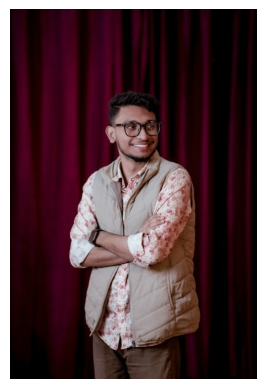

In [5]:
print(test_df["image_path"].iloc[0])
img = cv2.imread(test_df["image_path"].iloc[0])
answer = test_df["answer"].iloc[0]
print("Answer:", answer)
print(img.shape)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# **3-Load The Model And Requirements**

In [6]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="none"
)

def masked_loss(y_true, y_pred):
    # compute per-token loss
    loss = loss_object(y_true, y_pred)

    # mask padding tokens (0 = PAD)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    loss = loss * mask

    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    # predicted word id
    y_pred_ids = tf.argmax(y_pred, axis=-1)

    # ensure same dtype
    y_true = tf.cast(y_true, tf.int32)
    y_pred_ids = tf.cast(y_pred_ids, tf.int32)

    # check matches
    matches = tf.cast(tf.equal(y_true, y_pred_ids), tf.float32)

    # mask padding
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)

    matches = matches * mask

    return tf.reduce_sum(matches) / tf.reduce_sum(mask)

In [7]:
vqa_model = tf.keras.models.load_model(
    r"LAST_FT.keras",
    custom_objects={"masked_loss": masked_loss,
                    "masked_accuracy": masked_accuracy}
)

with open(r"question_vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

Q_vectorizer = TextVectorization(
    max_tokens=len(vocab),
    output_mode="int",
    output_sequence_length=32
)

Q_vectorizer.set_vocabulary(vocab)


with open(r"answer_vocab.pkl", "rb") as f:
    vocab = pickle.load(f)

A_vectorizer = TextVectorization(
    max_tokens=len(vocab),
    output_mode="int",
    output_sequence_length=12
)

A_vectorizer.set_vocabulary(vocab)

In [8]:
def preprocess_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img

# **4-Showing Some Vocabs**

In [9]:
idx_to_word = np.array(Q_vectorizer.get_vocabulary())
word_to_idx = {word: i for i, word in enumerate(idx_to_word)}

print("Sample vocab Question:", idx_to_word[:50])
print()

idx_to_word = np.array(A_vectorizer.get_vocabulary())
word_to_idx = {word: i for i, word in enumerate(idx_to_word)}

print("Sample vocab Answer:", idx_to_word[:50])

Sample vocab Question: ['' '[UNK]' 'start' 'end' 'the' 'what' 'is' 'image' 'in' 'of' 'this' 'you'
 'visible' 'describe' 'subject' 'main' 'overall' 'or' 'scene' 'can'
 'details' 'are' 'how' 'would' 'mood' 'photo' 'outdoor' 'indoor' 'an'
 'picture' 'persons' 'appearance' 'shown' 'summarize' 'taking' 'place'
 'activity' 'be' 'photograph' 'happening' 'observed' 'focus' 'from'
 'infer' 'stands' 'out' 'most' 'kind' 'elements' 'clearly']

Sample vocab Answer: ['' '[UNK]' 'start' 'the' 'a' 'image' 'is' 'end' 'of' 'be' 'subject'
 'main' 'in' 'scene' 'it' 'clearly' 'can' 'shows' 'they' 'features' 'and'
 'closeup' 'on' 'an' 'appear' 'conveys' 'sense' 'setting' 'white' 'to'
 'appears' 'black' 'not' 'defined' 'focus' 'photo' 'with' 'shown'
 'visible' 'as' 'this' 'summarized' 'photograph' 'captures' 'details'
 'several' 'depicts' 'include' 'reflects' 'that']


# **5-Generate Caption Beam Search**

In [10]:
A_MAX_LEN = 12
Q_MAX_LEN = 32

# ← حطهم هنا برا الـ function
A_idx_to_word = np.array(A_vectorizer.get_vocabulary())
A_word_to_idx = {w: i for i, w in enumerate(A_idx_to_word)}
start_id      = A_word_to_idx.get("start", 1)
end_id        = A_word_to_idx.get("end",   2)

def predict_answer(image_path, question, model, max_len=A_MAX_LEN):
    img = preprocess_image(tf.constant(image_path))
    img = tf.expand_dims(img, axis=0)

    q_seq    = Q_vectorizer(tf.constant([question]))
    q_seq    = q_seq[:, :Q_MAX_LEN - 1]
    pad_size = (Q_MAX_LEN - 1) - tf.shape(q_seq)[1]
    q_seq    = tf.pad(q_seq, [[0, 0], [0, pad_size]])

    answer_ids = [start_id]

    for _ in range(max_len - 1):
        a_seq = tf.keras.preprocessing.sequence.pad_sequences(
            [answer_ids], maxlen=A_MAX_LEN - 1, padding="post"
        )
        a_seq = tf.cast(a_seq, tf.int32)

        preds   = model.predict([img, q_seq, a_seq], verbose=0)
        next_id = int(np.argmax(preds[0, len(answer_ids) - 1]))

        if next_id == end_id or next_id == 0:
            break

        answer_ids.append(next_id)

    words = [
        A_idx_to_word[i]
        for i in answer_ids
        if i not in [0, start_id, end_id]
    ]
    return " ".join(words)

In [13]:
def predict_answer_beam(image_path, question, model, beam_width=3, max_len=A_MAX_LEN):
    img = preprocess_image(tf.constant(image_path))
    img = tf.expand_dims(img, axis=0)

    q_seq    = Q_vectorizer(tf.constant([question]))
    q_seq    = q_seq[:, :Q_MAX_LEN - 1]
    pad_size = (Q_MAX_LEN - 1) - tf.shape(q_seq)[1]
    q_seq    = tf.pad(q_seq, [[0, 0], [0, pad_size]])

    # ابدأ بـ start token
    sequences = [([start_id], 0.0)]
    completed = []

    for _ in range(max_len - 1):
        all_candidates = []

        for seq, score in sequences:
            if seq[-1] == end_id:
                completed.append((seq, score))
                continue

            a_seq = tf.keras.preprocessing.sequence.pad_sequences(
                [seq], maxlen=A_MAX_LEN - 1, padding="post"
            )
            a_seq = tf.cast(a_seq, tf.int32)

            preds    = model.predict([img, q_seq, a_seq], verbose=0)
            step_idx = min(len(seq) - 1, preds.shape[1] - 1)
            probs    = preds[0, step_idx]

            top_ids = np.argsort(probs)[-beam_width:][::-1]

            for token_id in top_ids:
                token_id = int(token_id)
                if token_id == 0:
                    continue
                new_seq   = seq + [token_id]
                new_score = score - np.log(probs[token_id] + 1e-10)
                all_candidates.append((new_seq, new_score))

        if not all_candidates:
            break

        sequences = sorted(all_candidates, key=lambda x: x[1] / len(x[0]))[:beam_width]

    final    = completed if completed else sequences
    best_seq = sorted(final, key=lambda x: x[1] / len(x[0]))[0][0]

    words = [
        A_idx_to_word[i]
        for i in best_seq
        if i not in [0, start_id, end_id] and i < len(A_idx_to_word)
    ]
    return " ".join(words)


# ====== Evaluation ======
sample_df = test_df.sample(20, random_state=55).reset_index(drop=True)
smooth    = SmoothingFunction().method1

correct = 0
total   = 0
bleu1_scores, bleu2_scores = [], []
bleu3_scores, bleu4_scores = [], []
meteor_scores              = []

for i, row in sample_df.iterrows():
    pred   = predict_answer_beam(row["image_path"], row["question"], vqa_model, beam_width=3)
    actual = row["answer"].strip().lower()
    pred   = pred.strip().lower()

    actual = actual.replace("start", "").replace("end", "").strip()
    pred   = pred.replace("start",   "").replace("end",   "").strip()

    ref_tokens  = actual.split()
    pred_tokens = pred.split()

    if not pred_tokens:
        continue

    correct += int(pred == actual)
    total   += 1

    ref = [ref_tokens]
    bleu1_scores.append(sentence_bleu(ref, pred_tokens, weights=(1,0,0,0),          smoothing_function=smooth))
    bleu2_scores.append(sentence_bleu(ref, pred_tokens, weights=(0.5,0.5,0,0),      smoothing_function=smooth))
    bleu3_scores.append(sentence_bleu(ref, pred_tokens, weights=(1/3,1/3,1/3,0),    smoothing_function=smooth))
    bleu4_scores.append(sentence_bleu(ref, pred_tokens, weights=(.25,.25,.25,.25),   smoothing_function=smooth))
    meteor_scores.append(meteor_score([ref_tokens], pred_tokens))

    img = cv2.imread(row["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print(f"Q:    {row['question']}\n")
    print(f"True: {actual}\n")
    print(f"Pred: {pred}"
    )


    print("-" * 50)

print(f"\nExact Match : {correct/total:.4f} ({correct}/{total})")
print(f"BLEU-1      : {np.mean(bleu1_scores):.4f}")
print(f"BLEU-2      : {np.mean(bleu2_scores):.4f}")
print(f"BLEU-3      : {np.mean(bleu3_scores):.4f}")
print(f"BLEU-4      : {np.mean(bleu4_scores):.4f}")
print(f"METEOR      : {np.mean(meteor_scores):.4f}")

Q:    start can you describe what is visible in the image end

True: the image shows speedway motorcycle race racing sports motorsport

Pred: it can be inferred that the image shows closeup of a
--------------------------------------------------
Q:    start describe the overall mood or scene of image end

True: the overall scene reflects a detailed closeup of an

Pred: the setting is not clearly defined
--------------------------------------------------
Q:    start what is the main subject of image end

True: the main subject is a sign

Pred: the main subject appears to be a vibrant red stop sign
--------------------------------------------------
Q:    start what is the dominant color in image end

True: black mountain bike parked near the road is dominant

Pred: the main subject appears to be a classic vintage bicycle with
--------------------------------------------------
Q:    start describe the overall mood or scene of image end

True: the overall scene reflects mount fuji kawaguch